# Deteccao de Anomalias em Turbinas Eolicas com CNN-BiLSTM-Attention Autoencoder (v3)
## Wind Farm C -- Dados SCADA

Pipeline completo para deteccao de anomalias em turbinas eolicas offshore utilizando
dados SCADA com resolucao de 10 minutos. O fluxo inclui pre-processamento, selecao
de features via XGBoost, treinamento de um autoencoder CNN-BiLSTM com camada de atencao
em PyTorch e avaliacao quantitativa da deteccao de falhas.

### Melhorias em relacao a v2
- **LSTM Bidirecional**: encoder LSTMs agora sao bidirecionais, capturando contexto
  temporal passado e futuro simultaneamente (decoder permanece unidirecional)
- **MAE como loss**: substituicao do MSE por MAE (L1Loss) para reconstrucao mais robusta
  a outliers
- **Threshold por feature**: em vez de um threshold global unico, cada feature tem seu
  proprio threshold (P95/P99). Uma janela e anomala se `>= MIN_FEATURES_EXCEED` features
  excedem seus thresholds individuais. Anomaly score continuo via max-ratio para AUC
- **Modo de treino reduzido (FAST_MODE)**: variaveis `FAST_MAX_EVENTS` e
  `FAST_MAX_TRAIN_WINDOWS` para limitar CSVs carregados e janelas de treino
- **Camada de atencao (Multi-Head Self-Attention)** no encoder com conexao residual e
  LayerNorm, agregacao via mean-pooling temporal

### Melhorias herdadas da v2 (em relacao a v1)
- Dropout reduzido (0.5 -> 0.15) para melhor capacidade de reconstrucao
- Batch size aumentado (32 -> 128) para treinamento mais eficiente
- Learning rate scheduler (ReduceLROnPlateau) para convergencia adaptativa
- XGBoost com `scale_pos_weight` para melhor selecao de features em dados desbalanceados
- Normalizacao sem clipping forcado, com diagnostico de valores fora de range
- Metricas AUC-ROC e AUC-PR para avaliacao independente de threshold
- Avaliacao por evento de anomalia (taxa de deteccao por evento)

In [1]:
import os
import gc
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve, auc
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {DEVICE}")

BASE_DIR = os.path.join('CARE_To_Compare', 'Wind Farm C')
DATASETS_DIR = os.path.join(BASE_DIR, 'datasets')
EVENT_INFO_PATH = os.path.join(BASE_DIR, 'event_info.csv')
FEATURE_DESC_PATH = os.path.join(BASE_DIR, 'feature_description.csv')
OUTPUT_DIR = 'artefatos_v3'
os.makedirs(OUTPUT_DIR, exist_ok=True)

WINDOW_SIZE = 36
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
FEATURE_TOP_PERCENT = 0.30
BATCH_SIZE = 128
EPOCHS = 10
PATIENCE = 5
LEARNING_RATE = 1e-3
DROPOUT_RATE = 0.15
MIN_FEATURES_EXCEED = 1

FAST_MODE = True
FAST_MAX_EVENTS = 15
FAST_MAX_TRAIN_WINDOWS = 100_000

META_COLS = ['time_stamp', 'asset_id', 'id', 'train_test', 'status_type_id']
HEALTHY_STATUS = [0, 2]

print(f"Janela temporal: {WINDOW_SIZE} steps ({WINDOW_SIZE * 10 / 60:.0f} horas)")
print(f"Split: {TRAIN_RATIO*100:.0f}% treino / {VAL_RATIO*100:.0f}% validacao / {TEST_RATIO*100:.0f}% teste")
print(f"Selecao de features: top {FEATURE_TOP_PERCENT*100:.0f}% (XGBoost)")
print(f"Batch size: {BATCH_SIZE}")
print(f"Dropout: {DROPOUT_RATE}")
print(f"Loss: MAE (L1)")
print(f"MIN_FEATURES_EXCEED: {MIN_FEATURES_EXCEED}")
print(f"Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)")
if FAST_MODE:
    print(f"FAST_MODE: ativado (max {FAST_MAX_EVENTS} CSVs, max {FAST_MAX_TRAIN_WINDOWS:,} janelas treino)")
else:
    print(f"FAST_MODE: desativado (dados completos)")

Dispositivo: cuda
Janela temporal: 36 steps (6 horas)
Split: 70% treino / 15% validacao / 15% teste
Selecao de features: top 30% (XGBoost)
Batch size: 128
Dropout: 0.15
Loss: MAE (L1)
MIN_FEATURES_EXCEED: 1
Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)
FAST_MODE: ativado (max 15 CSVs, max 100,000 janelas treino)


## 1. Carregamento dos Dados

Carregamento de todos os 58 datasets CSV do Wind Farm C e do arquivo de informacoes
de eventos. Cada dataset contem series temporais SCADA de uma turbina com resolucao
de 10 minutos e ate 957 features (sensores com estatisticas avg, min, max, std).

In [2]:
event_info = pd.read_csv(EVENT_INFO_PATH, sep=';')
event_info['event_start'] = pd.to_datetime(event_info['event_start'])
event_info['event_end'] = pd.to_datetime(event_info['event_end'])

print(f"Total de eventos: {len(event_info)}")
print(f"  Anomalias: {(event_info['event_label'] == 'anomaly').sum()}")
print(f"  Normais:   {(event_info['event_label'] == 'normal').sum()}")
print(f"  Turbinas unicas: {event_info['asset_id'].nunique()}")
event_info.head(10)

Total de eventos: 58
  Anomalias: 27
  Normais:   31
  Turbinas unicas: 22


,asset_id,event_id,event_label,event_start,event_start_id,event_end,event_end_id,event_description
0,50,55,anomaly,2023-10-29 11:30:00,52848,2023-11-15 15:30:00,55320,Harting plug Nacelle/HUB damaged + NCR20_HUB: ...
1,38,81,anomaly,2023-11-16 01:30:00,52704,2023-11-18 14:00:00,53067,Converter Failure from 17.11 12:30 - 18.11. 13...
2,21,47,anomaly,2023-12-22 15:00:00,52416,2023-12-27 13:40:00,53128,Failure due to Rotorbrake and Hydraulic proble...
3,2,12,anomaly,2023-06-27 00:00:00,52560,2023-07-19 15:00:00,55818,"10115 : Oil level error, two-pump mode + Oil L..."
4,34,4,anomaly,2023-07-31 10:00:00,52992,2023-08-19 10:00:00,55728,23020 : Axis 3 not ready-to-operate
5,34,18,anomaly,2023-09-13 00:00:00,51408,2023-09-16 23:50:00,51983,We had some failures (störung 24VAC Versorgung...
6,52,28,anomaly,2023-05-28 13:00:00,52704,2023-06-17 20:30:00,55629,P20_spinner_carbonbrush defekt + P20_Accumulat...
7,52,39,anomaly,2023-10-19 13:00:00,52848,2023-10-24 15:20:00,53582,15004 : Safety chain relay open + 93005 : Gear...
8,12,66,anomaly,2023-01-17 00:00:00,51696,2023-01-23 13:00:00,52638,"Pitchfailure - defect Beckhoffcard, Axis 2, re..."
9,12,15,anomaly,2023-02-06 00:00:00,51984,2023-02-23 00:00:00,54432,Randomn small failures regarding pitch resulti...


In [3]:
csv_files = sorted([f for f in os.listdir(DATASETS_DIR) if f.endswith('.csv')])
print(f"Total de arquivos CSV encontrados: {len(csv_files)}")

if FAST_MODE and FAST_MAX_EVENTS and len(csv_files) > FAST_MAX_EVENTS:
    csv_files = csv_files[:FAST_MAX_EVENTS]
    print(f"  FAST_MODE: limitado a {FAST_MAX_EVENTS} arquivos CSV")

print("Passo 1: coletando timestamps para definir cortes do split temporal...")
all_ts = []
for csv_file in csv_files:
    ts = pd.read_csv(os.path.join(DATASETS_DIR, csv_file),
                     sep=';', usecols=['time_stamp'])['time_stamp']
    all_ts.append(pd.to_datetime(ts))

all_ts = pd.concat(all_ts).sort_values().reset_index(drop=True)
n_total = len(all_ts)
ts_train_cutoff = all_ts.iloc[int(n_total * TRAIN_RATIO)]
ts_val_cutoff   = all_ts.iloc[int(n_total * (TRAIN_RATIO + VAL_RATIO))]
del all_ts; gc.collect()

print(f"  Amostras totais: {n_total:,}")
print(f"  Corte treino/val: {ts_train_cutoff}")
print(f"  Corte val/teste:  {ts_val_cutoff}")

sample_header = pd.read_csv(os.path.join(DATASETS_DIR, csv_files[0]), sep=';', nrows=0)
scols_all = [c for c in sample_header.columns if c not in META_COLS]
dtype_map = {c: np.float32 for c in scols_all}

print("\nPasso 2: processamento por arquivo (ffill + labeling + split)...")
anomaly_dict = {}
for _, row in event_info[event_info['event_label'] == 'anomaly'].iterrows():
    anomaly_dict[row['event_id']] = (row['event_start'], row['event_end'])

train_parts, val_parts, test_parts = [], [], []

for i, csv_file in enumerate(csv_files):
    event_id = int(csv_file.replace('.csv', ''))
    filepath = os.path.join(DATASETS_DIR, csv_file)

    df = pd.read_csv(filepath, sep=';', dtype=dtype_map)
    df['event_id'] = event_id
    df['time_stamp'] = pd.to_datetime(df['time_stamp'])

    scols = [c for c in df.columns if c not in META_COLS + ['event_id']]
    df[scols] = df[scols].ffill()
    df[scols] = df[scols].bfill()

    df['label'] = 0
    if event_id in anomaly_dict:
        es, ee = anomaly_dict[event_id]
        mask_anom = (df['time_stamp'] >= es) & (df['time_stamp'] <= ee)
        df.loc[mask_anom, 'label'] = 1

    df['is_healthy'] = (
        (df['label'] == 0) & df['status_type_id'].isin(HEALTHY_STATUS)
    ).astype(np.int8)

    m_tr = df['time_stamp'] < ts_train_cutoff
    m_va = (df['time_stamp'] >= ts_train_cutoff) & (df['time_stamp'] < ts_val_cutoff)
    m_te = df['time_stamp'] >= ts_val_cutoff

    if m_tr.any(): train_parts.append(df.loc[m_tr])
    if m_va.any(): val_parts.append(df.loc[m_va])
    if m_te.any(): test_parts.append(df.loc[m_te])

    del df
    if (i + 1) % 10 == 0:
        gc.collect()
    if (i + 1) % 20 == 0 or (i + 1) == len(csv_files):
        print(f"  Processados: {i + 1}/{len(csv_files)}")

print("\nConcatenando e ordenando splits...")

df_train = pd.concat(train_parts, ignore_index=True)
del train_parts; gc.collect()
df_train.sort_values('time_stamp', inplace=True)
df_train.reset_index(drop=True, inplace=True)

df_val = pd.concat(val_parts, ignore_index=True)
del val_parts; gc.collect()
df_val.sort_values('time_stamp', inplace=True)
df_val.reset_index(drop=True, inplace=True)

df_test = pd.concat(test_parts, ignore_index=True)
del test_parts; gc.collect()
df_test.sort_values('time_stamp', inplace=True)
df_test.reset_index(drop=True, inplace=True)

n = len(df_train) + len(df_val) + len(df_test)
for name, sp in [('Treino', df_train), ('Validacao', df_val), ('Teste', df_test)]:
    ns = len(sp)
    mem = sp.memory_usage(deep=True).sum() / 1e6
    print(f"  {name:10s}: {ns:>7,} amostras ({ns/n*100:5.1f}%) | "
          f"Anomalias: {(sp['label']==1).sum():>5,} | "
          f"Saudaveis: {(sp['is_healthy']==1).sum():>7,} | "
          f"Mem: {mem:,.0f} MB")

Total de arquivos CSV encontrados: 58
  FAST_MODE: limitado a 15 arquivos CSV
Passo 1: coletando timestamps para definir cortes do split temporal...
  Amostras totais: 821,391
  Corte treino/val: 2023-05-07 10:50:00
  Corte val/teste:  2023-07-23 08:30:00

Passo 2: processamento por arquivo (ffill + labeling + split)...
  Processados: 15/15

Concatenando e ordenando splits...
  Treino    : 574,966 amostras ( 70.0%) | Anomalias: 3,470 | Saudaveis: 521,154 | Mem: 2,249 MB
  Validacao : 123,209 amostras ( 15.0%) | Anomalias: 6,185 | Saudaveis:  98,922 | Mem: 482 MB
  Teste     : 123,216 amostras ( 15.0%) | Anomalias: 12,956 | Saudaveis:  90,116 | Mem: 482 MB


## 2. Rotulacao (Labeling)

Criacao de labels binarios para cada amostra:
- **0 (saudavel)**: timestamp fora de qualquer periodo de anomalia
- **1 (anomalia)**: timestamp dentro do periodo `[event_start, event_end]` de um evento
  classificado como anomalia no `event_info.csv`

Adicionalmente, definimos o conceito de amostra **estritamente saudavel** como aquela
com `label=0` e `status_type_id` em {0 (operacao normal), 2 (idling)}. Somente estas
amostras serao usadas para treinar o autoencoder, garantindo que o modelo aprenda
exclusivamente o comportamento normal da turbina.

In [4]:
all_labels = pd.concat([df_train['label'], df_val['label'], df_test['label']])
all_healthy = pd.concat([df_train['is_healthy'], df_val['is_healthy'], df_test['is_healthy']])
all_status = pd.concat([df_train['status_type_id'], df_val['status_type_id'], df_test['status_type_id']])

print("Distribuicao de labels (todos os splits combinados):")
print(f"  Saudavel (0):  {(all_labels == 0).sum():,} "
      f"({(all_labels == 0).mean()*100:.1f}%)")
print(f"  Anomalia (1):  {(all_labels == 1).sum():,} "
      f"({(all_labels == 1).mean()*100:.1f}%)")
print(f"\nAmostras estritamente saudaveis (label=0 e status normal/idling): "
      f"{(all_healthy == 1).sum():,} ({(all_healthy == 1).mean()*100:.1f}%)")
print(f"\nDistribuicao de status_type_id:")
print(all_status.value_counts().sort_index().to_string())
del all_labels, all_healthy, all_status

Distribuicao de labels (todos os splits combinados):
  Saudavel (0):  798,780 (97.2%)
  Anomalia (1):  22,611 (2.8%)

Amostras estritamente saudaveis (label=0 e status normal/idling): 710,192 (86.5%)

Distribuicao de status_type_id:
status_type_id
0    724265
3     68621
4      8019
5     20486


## 3. Divisao Temporal dos Dados

Divisao estritamente temporal (70% treino / 15% validacao / 15% teste) baseada na
ordenacao global por timestamp. Em series temporais, a divisao aleatoria e proibida
pois causa vazamento de informacao temporal (data leakage).

O scaler e o XGBoost serao ajustados **somente** nos dados de treino.

In [5]:
n = len(df_train) + len(df_val) + len(df_test)

print("Verificacao da divisao temporal (ja realizada na etapa de carregamento):\n")
for name, split in [('Treino', df_train), ('Validacao', df_val), ('Teste', df_test)]:
    n_total = len(split)
    n_anom = (split['label'] == 1).sum()
    n_healthy = (split['is_healthy'] == 1).sum()
    print(f"{name:10s}: {n_total:>7,} amostras ({n_total/n*100:5.1f}%) | "
          f"Anomalias: {n_anom:>5,} | Saudaveis: {n_healthy:>7,} | "
          f"Periodo: {split['time_stamp'].min()} -- {split['time_stamp'].max()}")

print(f"\nCorte treino/val: {ts_train_cutoff}")
print(f"Corte val/teste:  {ts_val_cutoff}")

Verificacao da divisao temporal (ja realizada na etapa de carregamento):

Treino    : 574,966 amostras ( 70.0%) | Anomalias: 3,470 | Saudaveis: 521,154 | Periodo: 2022-01-16 00:00:00 -- 2023-05-07 10:40:00
Validacao : 123,209 amostras ( 15.0%) | Anomalias: 6,185 | Saudaveis:  98,922 | Periodo: 2023-05-07 10:50:00 -- 2023-07-23 08:20:00
Teste     : 123,216 amostras ( 15.0%) | Anomalias: 12,956 | Saudaveis:  90,116 | Periodo: 2023-07-23 08:30:00 -- 2024-01-08 15:40:00

Corte treino/val: 2023-05-07 10:50:00
Corte val/teste:  2023-07-23 08:30:00


## 4. Normalizacao dos Dados

Normalizacao Min-Max para o intervalo [0, 1] aplicada a todas as features de sensores.
O scaler e ajustado **exclusivamente** nos dados de treino para evitar vazamento de
informacao (data leakage). Os conjuntos de validacao e teste sao transformados com
os parametros aprendidos no treino.

**Melhoria v2**: sem clipping forcado -- valores fora de [0, 1] sao preservados e
diagnosticados, pois podem indicar data drift ou distribuicoes diferentes entre splits.

In [6]:
sensor_cols = [c for c in df_train.columns
              if c not in META_COLS + ['event_id', 'label', 'is_healthy']]
print(f"Total de features de sensores: {len(sensor_cols)}")

scaler = MinMaxScaler(feature_range=(0, 1))
CHUNK_FIT = 50_000
for start in range(0, len(df_train), CHUNK_FIT):
    end = min(start + CHUNK_FIT, len(df_train))
    scaler.partial_fit(df_train[sensor_cols].iloc[start:end])

print("Scaler ajustado via partial_fit (sem converter tudo para float64)")

scale_ = scaler.scale_.astype(np.float32)
min_   = scaler.min_.astype(np.float32)

for split_name, df_split in [('Treino', df_train), ('Validacao', df_val), ('Teste', df_test)]:
    n_oor = 0
    for i, col in enumerate(sensor_cols):
        vals = df_split[col].values * scale_[i] + min_[i]
        out_of_range = int(((vals < 0) | (vals > 1)).sum())
        n_oor += out_of_range
        df_split[col] = vals
    gc.collect()
    n_total_vals = len(df_split) * len(sensor_cols)
    print(f"  {split_name} normalizado | Valores fora de [0,1]: {n_oor:,} "
          f"({n_oor/n_total_vals*100:.4f}%)")

del scale_, min_; gc.collect()

print("\nNormalizacao concluida (MinMaxScaler ajustado somente no treino, sem clipping)")
for name, split in [('Treino', df_train), ('Validacao', df_val), ('Teste', df_test)]:
    vals = split[sensor_cols]
    print(f"  {name:10s} - min: {vals.min().min():.4f}, "
          f"max: {vals.max().max():.4f}, media: {vals.mean().mean():.4f}")

Total de features de sensores: 952
Scaler ajustado via partial_fit (sem converter tudo para float64)
  Treino normalizado | Valores fora de [0,1]: 7,098 (0.0013%)
  Validacao normalizado | Valores fora de [0,1]: 53,395 (0.0455%)
  Teste normalizado | Valores fora de [0,1]: 77,058 (0.0657%)

Normalizacao concluida (MinMaxScaler ajustado somente no treino, sem clipping)
  Treino     - min: 0.0000, max: 1.0000, media: 0.4373
  Validacao  - min: -56.0120, max: 59.7787, media: 0.4268
  Teste      - min: -13.7691, max: 25.3143, media: 0.4344


## 5. Selecao de Features com XGBoost

Utilizacao do XGBoost para classificacao binaria (saudavel vs anomalia) nos dados de
treino. As features sao rankeadas por importancia (`feature_importances_`) e as top
30% sao selecionadas, reduzindo a dimensionalidade e mantendo as variaveis mais
relevantes para a deteccao de falhas.

**Melhoria v2**: `scale_pos_weight` calculado automaticamente a partir do ratio de
desbalanceamento das classes, garantindo que a classe minoritaria (anomalia) tenha
peso proporcional na selecao de features.

In [7]:
MAX_XGB_SAMPLES = 200_000
if len(df_train) > MAX_XGB_SAMPLES:
    rng = np.random.RandomState(SEED)
    sample_idx = rng.choice(len(df_train), MAX_XGB_SAMPLES, replace=False)
    sample_idx.sort()
    X_train_xgb = df_train[sensor_cols].iloc[sample_idx].values
    y_train_xgb = df_train['label'].iloc[sample_idx].values
    print(f"Subamostra para XGBoost: {MAX_XGB_SAMPLES:,} de {len(df_train):,}")
else:
    X_train_xgb = df_train[sensor_cols].values
    y_train_xgb = df_train['label'].values

neg_count = int((y_train_xgb == 0).sum())
pos_count = int((y_train_xgb == 1).sum())
spw = neg_count / max(pos_count, 1)

print(f"Treinando XGBoost: {X_train_xgb.shape[0]:,} amostras, {X_train_xgb.shape[1]} features")
print(f"  Classes: 0={neg_count:,}  1={pos_count:,}")
print(f"  scale_pos_weight: {spw:.2f}")

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=spw,
    random_state=SEED,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_model.fit(X_train_xgb, y_train_xgb)

importances = xgb_model.feature_importances_.copy()
feature_importance_df = pd.DataFrame({
    'feature': sensor_cols,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

n_selected = max(1, int(len(sensor_cols) * FEATURE_TOP_PERCENT))
selected_features = feature_importance_df.head(n_selected)['feature'].tolist()

print(f"\nFeatures originais: {len(sensor_cols)}")
print(f"Features selecionadas (top {FEATURE_TOP_PERCENT*100:.0f}%): {n_selected}")
print(f"\nTop 20 features mais importantes:")
print(feature_importance_df.head(20).to_string())

del X_train_xgb, y_train_xgb; gc.collect()

Subamostra para XGBoost: 200,000 de 574,966
Treinando XGBoost: 200,000 amostras, 952 features
  Classes: 0=198,790  1=1,210
  scale_pos_weight: 164.29

Features originais: 952
Features selecionadas (top 30%): 285

Top 20 features mais importantes:
               feature  importance
0        sensor_93_avg    0.300075
1        sensor_74_avg    0.202419
2       sensor_210_avg    0.049986
3       sensor_210_min    0.040728
4        sensor_99_min    0.031094
5        sensor_74_min    0.025749
6       sensor_227_avg    0.020093
7       sensor_227_min    0.015986
8        sensor_39_avg    0.014758
9       sensor_225_max    0.014216
10  wind_speed_235_min    0.013319
11       sensor_98_min    0.013132
12       sensor_36_max    0.011603
13       sensor_99_avg    0.010545
14       sensor_35_max    0.008828
15      sensor_108_min    0.008684
16       sensor_66_min    0.008513
17       sensor_35_std    0.007939
18       sensor_14_std    0.007347
19       sensor_25_min    0.006533


40

In [8]:
keep_cols = ['time_stamp', 'event_id', 'label', 'is_healthy']
df_train_sel = df_train[keep_cols + selected_features].copy()
df_val_sel = df_val[keep_cols + selected_features].copy()
df_test_sel = df_test[keep_cols + selected_features].copy()

del df_train, df_val, df_test
gc.collect()

print("Dimensao apos selecao de features:")
print(f"  Treino:    {df_train_sel.shape}")
print(f"  Validacao: {df_val_sel.shape}")
print(f"  Teste:     {df_test_sel.shape}")

Dimensao apos selecao de features:
  Treino:    (574966, 289)
  Validacao: (123209, 289)
  Teste:     (123216, 289)


## 6. Criacao de Janelas Temporais

Criacao de janelas deslizantes de 36 timesteps (equivalente a 6 horas com dados de
10 em 10 minutos). As janelas sao construidas **dentro de cada dataset** (mesmo
`event_id`) para nao misturar dados de diferentes turbinas ou eventos.

- **Janela saudavel**: todos os 36 timesteps possuem `is_healthy=1`
- **Janela com anomalia**: pelo menos 1 timestep possui `label=1`

In [9]:
def build_window_index(df, window_size, feature_cols):
    """Build per-group flat arrays and window metadata without materializing windows.

    Instead of storing an (N, W, F) tensor (~91 GB for training), we keep the
    flat feature arrays per event_id and a compact index of (eid, start, label,
    healthy) per window.  Windows are constructed on-the-fly in WindowDataset.
    """
    group_arrays = {}
    all_eid, all_start, all_label, all_healthy = [], [], [], []

    for eid, group in df.groupby('event_id'):
        group = group.sort_values('time_stamp').reset_index(drop=True)
        group_arrays[eid] = group[feature_cols].values.astype(np.float32)
        labels  = group['label'].values.astype(np.int8)
        healthy = group['is_healthy'].values.astype(np.int8)

        n = len(group)
        if n < window_size:
            continue

        nw = n - window_size + 1
        cum_l = np.concatenate([[0], np.cumsum(labels)])
        cum_h = np.concatenate([[0], np.cumsum(healthy)])
        w_labels  = (cum_l[window_size:] - cum_l[:nw] > 0).astype(np.int8)
        w_healthy = (cum_h[window_size:] - cum_h[:nw] == window_size).astype(np.int8)

        all_eid.append(np.full(nw, eid, dtype=np.int32))
        all_start.append(np.arange(nw, dtype=np.int32))
        all_label.append(w_labels)
        all_healthy.append(w_healthy)

    return (group_arrays,
            np.concatenate(all_eid),
            np.concatenate(all_start),
            np.concatenate(all_label),
            np.concatenate(all_healthy))


class WindowDataset(torch.utils.data.Dataset):
    """Memory-efficient dataset: builds each window on-the-fly from flat arrays."""
    def __init__(self, group_arrays, eids, starts, window_size):
        self.ga     = group_arrays
        self.eids   = eids
        self.starts = starts
        self.ws     = window_size

    def __len__(self):
        return len(self.eids)

    def __getitem__(self, idx):
        e = int(self.eids[idx])
        s = int(self.starts[idx])
        return torch.from_numpy(self.ga[e][s:s + self.ws].copy())


ga_train, eid_tr, start_tr, y_train, h_train = build_window_index(
    df_train_sel, WINDOW_SIZE, selected_features)
del df_train_sel; gc.collect()

ga_val, eid_va, start_va, y_val, h_val = build_window_index(
    df_val_sel, WINDOW_SIZE, selected_features)
del df_val_sel; gc.collect()

ga_test, eid_te, start_te, y_test, h_test = build_window_index(
    df_test_sel, WINDOW_SIZE, selected_features)
del df_test_sel; gc.collect()

n_features = len(selected_features)
print(f"Indices de janelas criados (window_size={WINDOW_SIZE}, features={n_features}):")
for name, eid_arr, y_arr, h_arr in [
    ('Treino', eid_tr, y_train, h_train),
    ('Validacao', eid_va, y_val, h_val),
    ('Teste', eid_te, y_test, h_test)]:
    print(f"  {name:10s}: {len(eid_arr):>7,} janelas | "
          f"Anomalias: {y_arr.sum():,} | Saudaveis: {h_arr.sum():,}")

ga_mem = sum(a.nbytes for a in ga_train.values()) / 1e9
print(f"\nMemoria: ~{ga_mem:.1f} GB (treino) vs ~{ga_mem * WINDOW_SIZE:.0f} GB "
      f"se janelas fossem materializadas")

Indices de janelas criados (window_size=36, features=285):
  Treino    : 574,441 janelas | Anomalias: 3,505 | Saudaveis: 408,220
  Validacao : 122,789 janelas | Anomalias: 6,255 | Saudaveis: 74,996
  Teste     : 122,866 janelas | Anomalias: 13,131 | Saudaveis: 66,695

Memoria: ~0.7 GB (treino) vs ~24 GB se janelas fossem materializadas


In [10]:
healthy_mask_tr = (h_train == 1)
healthy_mask_va = (h_val == 1)

n_healthy_tr = int(healthy_mask_tr.sum())
n_healthy_va = int(healthy_mask_va.sum())

if FAST_MODE and FAST_MAX_TRAIN_WINDOWS and n_healthy_tr > FAST_MAX_TRAIN_WINDOWS:
    rng = np.random.RandomState(SEED)
    healthy_indices_all = np.where(healthy_mask_tr)[0]
    subsample_idx = rng.choice(len(healthy_indices_all), FAST_MAX_TRAIN_WINDOWS, replace=False)
    subsample_idx.sort()
    fast_mask = np.zeros(len(h_train), dtype=bool)
    fast_mask[healthy_indices_all[subsample_idx]] = True
    healthy_mask_tr = fast_mask
    n_healthy_tr_original = n_healthy_tr
    n_healthy_tr = FAST_MAX_TRAIN_WINDOWS
    print(f"FAST_MODE: sub-amostradas {n_healthy_tr:,} de {n_healthy_tr_original:,} janelas saudaveis de treino")

print("Janelas saudaveis para treinamento do autoencoder:")
print(f"  Treino:    ({n_healthy_tr}, {WINDOW_SIZE}, {n_features})")
print(f"  Validacao: ({n_healthy_va}, {WINDOW_SIZE}, {n_features})")

print(f"\nDimensoes de entrada do modelo:")
print(f"  Timesteps:  {WINDOW_SIZE}")
print(f"  Features:   {n_features}")

FAST_MODE: sub-amostradas 100,000 de 408,220 janelas saudaveis de treino
Janelas saudaveis para treinamento do autoencoder:
  Treino:    (100000, 36, 285)
  Validacao: (74996, 36, 285)

Dimensoes de entrada do modelo:
  Timesteps:  36
  Features:   285


## 7. Modelo CNN-BiLSTM-Attention Autoencoder (PyTorch)

Arquitetura do autoencoder projetada para aprender a representacao comprimida do
comportamento normal da turbina eolica.

**Encoder**: camadas convolucionais extraem padroes locais da serie temporal, seguidas
por **BiLSTMs** (bidirecionais) que capturam dependencias temporais passadas e futuras.
Uma camada de **Multi-Head Self-Attention** (4 heads, embed_dim=160) e aplicada sobre
a sequencia de saida das BiLSTMs, com conexao residual e LayerNorm. A saida e agregada
via mean-pooling temporal, produzindo o vetor latente de dimensao 160.

**Decoder**: reconstroi a serie temporal original a partir do vetor latente, utilizando
LSTMs unidirecionais e camadas densas.

O modelo e treinado **exclusivamente** com dados saudaveis usando **MAE (L1Loss)**.
Na inferencia, anomalias geram erros de reconstrucao elevados, permitindo sua deteccao.

**Melhorias v3**: BiLSTM no encoder, camada de atencao, MAE como loss.

In [11]:
class CNNBiLSTMAttentionAutoencoder(nn.Module):
    def __init__(self, n_features, timesteps, dropout_rate=0.15, n_heads=4):
        super().__init__()
        self.n_features = n_features
        self.timesteps = timesteps

        self.enc_conv1 = nn.Conv1d(n_features, 32, kernel_size=3)
        self.enc_pool1 = nn.MaxPool1d(2)
        self.enc_conv2 = nn.Conv1d(32, 64, kernel_size=2)
        self.enc_pool2 = nn.MaxPool1d(3)

        self.conv_out_len = ((timesteps - 2) // 2 - 1) // 3

        self.enc_lstm1 = nn.LSTM(64, 100, batch_first=True, bidirectional=True)
        self.enc_lstm2 = nn.LSTM(200, 80, batch_first=True, bidirectional=True)

        self.attention = nn.MultiheadAttention(
            embed_dim=160, num_heads=n_heads, batch_first=True, dropout=dropout_rate
        )
        self.attn_norm = nn.LayerNorm(160)

        self.dec_lstm1 = nn.LSTM(160, 80, batch_first=True)
        self.dec_lstm2 = nn.LSTM(80, 100, batch_first=True)

        self.dropout = nn.Dropout(dropout_rate)
        self.dec_fc1 = nn.Linear(100, 50)
        self.dec_fc2 = nn.Linear(50, 10)
        self.dec_fc3 = nn.Linear(10, n_features)

        self.selu = nn.SELU()

    def forward(self, x):
        batch_size = x.size(0)

        h = x.permute(0, 2, 1)
        h = self.selu(self.enc_conv1(h))
        h = self.enc_pool1(h)
        h = self.selu(self.enc_conv2(h))
        h = self.enc_pool2(h)

        h = h.permute(0, 2, 1)

        h, _ = self.enc_lstm1(h)
        h = self.selu(h)
        h, _ = self.enc_lstm2(h)
        h = self.selu(h)

        attn_out, _ = self.attention(h, h, h)
        h = self.attn_norm(h + attn_out)
        h = h.mean(dim=1)

        h = h.unsqueeze(1).repeat(1, self.timesteps, 1)

        h, _ = self.dec_lstm1(h)
        h = self.selu(h)
        h, _ = self.dec_lstm2(h)
        h = self.selu(h)

        h = self.dropout(h)
        h = self.selu(self.dec_fc1(h))
        h = self.selu(self.dec_fc2(h))
        h = self.dec_fc3(h)

        return h


model = CNNBiLSTMAttentionAutoencoder(n_features, WINDOW_SIZE, dropout_rate=DROPOUT_RATE).to(DEVICE)
print(model)
print(f"\nParametros treinaveis: "
      f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Dropout rate: {DROPOUT_RATE}")

CNNBiLSTMAttentionAutoencoder(
  (enc_conv1): Conv1d(285, 32, kernel_size=(3,), stride=(1,))
  (enc_pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc_conv2): Conv1d(32, 64, kernel_size=(2,), stride=(1,))
  (enc_pool2): MaxPool1d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
  (enc_lstm1): LSTM(64, 100, batch_first=True, bidirectional=True)
  (enc_lstm2): LSTM(200, 80, batch_first=True, bidirectional=True)
  (attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=160, out_features=160, bias=True)
  )
  (attn_norm): LayerNorm((160,), eps=1e-05, elementwise_affine=True)
  (dec_lstm1): LSTM(160, 80, batch_first=True)
  (dec_lstm2): LSTM(80, 100, batch_first=True)
  (dropout): Dropout(p=0.15, inplace=False)
  (dec_fc1): Linear(in_features=100, out_features=50, bias=True)
  (dec_fc2): Linear(in_features=50, out_features=10, bias=True)
  (dec_fc3): Linear(in_features=10, out_features=285, bias=True

## 8. Treinamento do Autoencoder

O modelo e treinado para minimizar o **MAE (Mean Absolute Error / L1Loss)** entre a
entrada (serie temporal original) e a saida (serie temporal reconstruida), utilizando
**somente janelas de dados saudaveis**.

- **Loss**: MAE (L1Loss)
- **Optimizer**: Adam (lr=0.001)
- **Scheduler**: ReduceLROnPlateau (factor=0.5, patience=3)
- **Batch size**: 128
- **Epochs**: configuravel com EarlyStopping (patience=5, monitorando val_loss)

**Melhorias v3**: MAE substitui MSE para maior robustez a outliers. Quando
`FAST_MODE=True`, o numero de janelas de treino e sub-amostrado para acelerar
a iteracao.

In [12]:
train_dataset = WindowDataset(ga_train, eid_tr[healthy_mask_tr],
                              start_tr[healthy_mask_tr], WINDOW_SIZE)
val_dataset = WindowDataset(ga_val, eid_va[healthy_mask_va],
                            start_va[healthy_mask_va], WINDOW_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=0, pin_memory=True)

criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, verbose=False
)

train_losses = []
val_losses = []
lr_history = []
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

print(f"Iniciando treinamento: {len(train_dataset):,} amostras treino, "
      f"{len(val_dataset):,} amostras validacao")
print(f"Batch size: {BATCH_SIZE} | LR inicial: {LEARNING_RATE}\n")

for epoch in range(EPOCHS):
    model.train()
    epoch_train_loss = 0.0
    for batch_x in train_loader:
        batch_x = batch_x.to(DEVICE)
        optimizer.zero_grad()
        output = model(batch_x)
        loss = criterion(output, batch_x)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * batch_x.size(0)
    epoch_train_loss /= len(train_dataset)

    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for batch_x in val_loader:
            batch_x = batch_x.to(DEVICE)
            output = model(batch_x)
            loss = criterion(output, batch_x)
            epoch_val_loss += loss.item() * batch_x.size(0)
    epoch_val_loss /= len(val_dataset)

    current_lr = optimizer.param_groups[0]['lr']
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    lr_history.append(current_lr)

    scheduler.step(epoch_val_loss)
    new_lr = optimizer.param_groups[0]['lr']

    marker = ''
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        marker = ' << melhor'
    else:
        patience_counter += 1

    lr_msg = f' (LR reducido: {current_lr:.2e} -> {new_lr:.2e})' if new_lr < current_lr else ''
    print(f"Epoca {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {epoch_train_loss:.6f} | "
          f"Val Loss: {epoch_val_loss:.6f} | "
          f"LR: {current_lr:.2e}{marker}{lr_msg}")

    if patience_counter >= PATIENCE:
        print(f"\nEarlyStopping na epoca {epoch+1} (paciencia={PATIENCE})")
        break

model.load_state_dict(best_model_state)
print(f"\nMelhor val_loss: {best_val_loss:.6f}")

Iniciando treinamento: 100,000 amostras treino, 74,996 amostras validacao
Batch size: 128 | LR inicial: 0.001

Epoca 01/10 | Train Loss: 0.096498 | Val Loss: 0.062599 | LR: 1.00e-03 << melhor
Epoca 02/10 | Train Loss: 0.063260 | Val Loss: 0.062169 | LR: 1.00e-03 << melhor
Epoca 03/10 | Train Loss: 0.063077 | Val Loss: 0.061761 | LR: 1.00e-03 << melhor
Epoca 04/10 | Train Loss: 0.062738 | Val Loss: 0.063660 | LR: 1.00e-03
Epoca 05/10 | Train Loss: 0.060049 | Val Loss: 0.056895 | LR: 1.00e-03 << melhor
Epoca 06/10 | Train Loss: 0.057247 | Val Loss: 0.055311 | LR: 1.00e-03 << melhor
Epoca 07/10 | Train Loss: 0.054173 | Val Loss: 0.049076 | LR: 1.00e-03 << melhor
Epoca 08/10 | Train Loss: 0.046571 | Val Loss: 0.043042 | LR: 1.00e-03 << melhor
Epoca 09/10 | Train Loss: 0.042682 | Val Loss: 0.040063 | LR: 1.00e-03 << melhor
Epoca 10/10 | Train Loss: 0.040362 | Val Loss: 0.039988 | LR: 1.00e-03 << melhor

Melhor val_loss: 0.039988


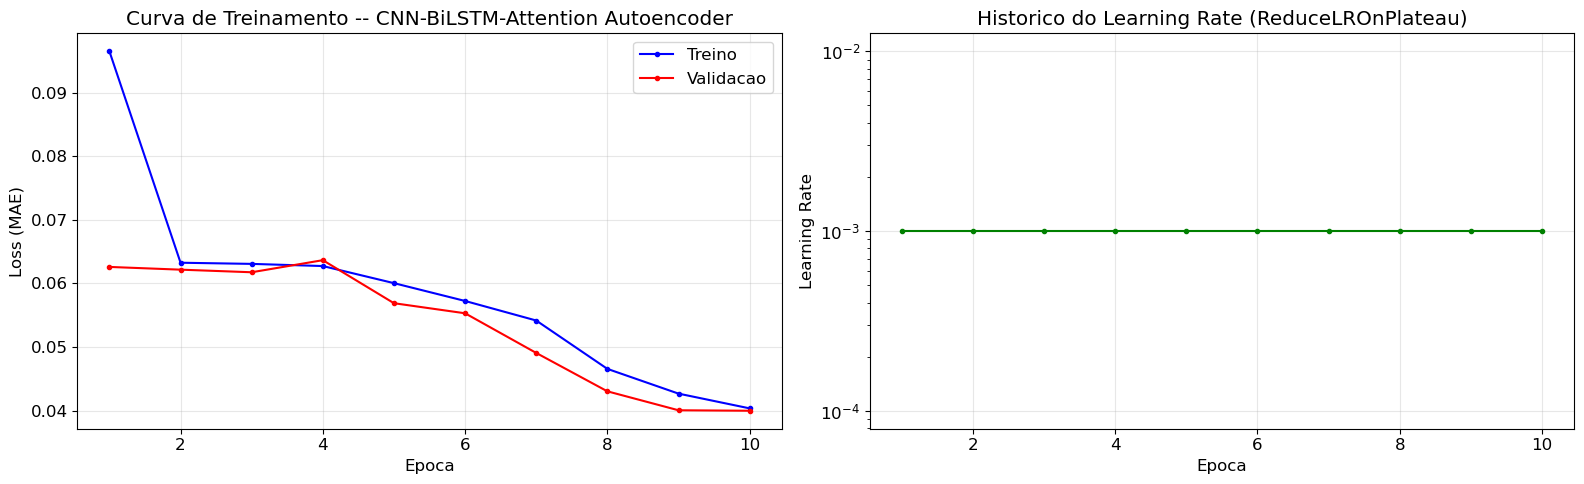

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.plot(range(1, len(train_losses) + 1), train_losses, 'b-o',
        markersize=3, label='Treino')
ax1.plot(range(1, len(val_losses) + 1), val_losses, 'r-o',
        markersize=3, label='Validacao')
ax1.set_xlabel('Epoca')
ax1.set_ylabel('Loss (MAE)')
ax1.set_title('Curva de Treinamento -- CNN-BiLSTM-Attention Autoencoder')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, len(lr_history) + 1), lr_history, 'g-o', markersize=3)
ax2.set_xlabel('Epoca')
ax2.set_ylabel('Learning Rate')
ax2.set_title('Historico do Learning Rate (ReduceLROnPlateau)')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Deteccao de Anomalias (Per-Feature Threshold)

Calculo do erro de reconstrucao **MAE por feature** (media sobre timesteps para cada
feature) e definicao de limiares **individuais por feature**.

- **Thresholds per-feature**: P95 e P99 de cada feature calculados nas janelas saudaveis
  de validacao. Cada feature tem seu proprio limiar.
- **Classificacao binaria**: uma janela e anomala se `>= MIN_FEATURES_EXCEED` features
  excedem seus thresholds individuais.
- **Anomaly score** (continuo): `max(error_i / threshold_i)` sobre todas as features,
  usado para AUC-ROC, AUC-PR e otimizacao do threshold Best-F1 via curva PR.

In [14]:
def compute_reconstruction_errors(model, dataset, per_feature_thresholds=None, batch_size=256):
    """Calcula MAE por feature e anomaly score por janela.

    Returns:
        pf_errors: (n_windows, n_features) -- MAE por feature (media sobre timesteps)
        anomaly_scores: (n_windows,) -- max(error_i / threshold_i) se thresholds fornecidos,
                        senao media global do MAE
    """
    model.eval()
    pf_errors_list = []
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        num_workers=0, pin_memory=True)

    with torch.no_grad():
        for batch_x in loader:
            batch_x = batch_x.to(DEVICE)
            output = model(batch_x)
            pf_mae = (output - batch_x).abs().mean(dim=1)
            pf_errors_list.append(pf_mae.cpu().numpy())

    pf_errors = np.vstack(pf_errors_list)
    if per_feature_thresholds is not None:
        anomaly_scores = (pf_errors / (per_feature_thresholds + 1e-10)).max(axis=1)
    else:
        anomaly_scores = pf_errors.mean(axis=1)
    return pf_errors, anomaly_scores


ds_train_h  = WindowDataset(ga_train, eid_tr[healthy_mask_tr],
                            start_tr[healthy_mask_tr], WINDOW_SIZE)
ds_val_h    = WindowDataset(ga_val, eid_va[healthy_mask_va],
                            start_va[healthy_mask_va], WINDOW_SIZE)
ds_val_all  = WindowDataset(ga_val, eid_va, start_va, WINDOW_SIZE)
ds_test_all = WindowDataset(ga_test, eid_te, start_te, WINDOW_SIZE)

pf_errors_train_h, _ = compute_reconstruction_errors(model, ds_train_h)
pf_errors_val_h, _   = compute_reconstruction_errors(model, ds_val_h)

print("Erros de reconstrucao por feature (MAE) -- janelas saudaveis:")
print(f"  Treino    - media global: {pf_errors_train_h.mean():.6f}, "
      f"std global: {pf_errors_train_h.mean(axis=0).std():.6f}, "
      f"max feature media: {pf_errors_train_h.mean(axis=0).max():.6f}")
print(f"  Validacao - media global: {pf_errors_val_h.mean():.6f}, "
      f"std global: {pf_errors_val_h.mean(axis=0).std():.6f}, "
      f"max feature media: {pf_errors_val_h.mean(axis=0).max():.6f}")

Erros de reconstrucao por feature (MAE) -- janelas saudaveis:
  Treino    - media global: 0.039873, std global: 0.067430, max feature media: 0.412289
  Validacao - media global: 0.039988, std global: 0.069494, max feature media: 0.448025


In [15]:
thresholds_pf_p95 = np.percentile(pf_errors_val_h, 95, axis=0)
thresholds_pf_p99 = np.percentile(pf_errors_val_h, 99, axis=0)

print(f"Thresholds per-feature (baseados nas janelas saudaveis de validacao):")
print(f"  P95 -- min: {thresholds_pf_p95.min():.6f}, "
      f"media: {thresholds_pf_p95.mean():.6f}, "
      f"max: {thresholds_pf_p95.max():.6f}")
print(f"  P99 -- min: {thresholds_pf_p99.min():.6f}, "
      f"media: {thresholds_pf_p99.mean():.6f}, "
      f"max: {thresholds_pf_p99.max():.6f}")
print(f"  Shape: ({len(thresholds_pf_p95)},) features")

pf_errors_val_all, scores_val_all = compute_reconstruction_errors(
    model, ds_val_all, per_feature_thresholds=thresholds_pf_p95)
pf_errors_test_all, scores_test_all = compute_reconstruction_errors(
    model, ds_test_all, per_feature_thresholds=thresholds_pf_p95)

print(f"\nAnomaly scores (max-ratio com P95):")
print(f"  Validacao - media: {scores_val_all.mean():.4f}, max: {scores_val_all.max():.4f}")
print(f"  Teste     - media: {scores_test_all.mean():.4f}, max: {scores_test_all.max():.4f}")

Thresholds per-feature (baseados nas janelas saudaveis de validacao):
  P95 -- min: 0.001628, media: 0.114240, max: 0.907222
  P99 -- min: 0.002057, media: 0.154759, max: 0.983268
  Shape: (285,) features

Anomaly scores (max-ratio com P95):
  Validacao - media: 33.3348, max: 409.4771
  Teste     - media: 47.6735, max: 409.4699


In [16]:
precisions_pr, recalls_pr, thresholds_pr = precision_recall_curve(y_val, scores_val_all)
f1_scores_pr = 2 * (precisions_pr * recalls_pr) / (precisions_pr + recalls_pr + 1e-8)
best_f1_idx = np.argmax(f1_scores_pr)
threshold_best_f1_score = float(thresholds_pr[best_f1_idx])

print("Threshold otimizado via curva Precision-Recall (no anomaly score de validacao):")
print(f"  Threshold Best-F1 (score): {threshold_best_f1_score:.4f}")
print(f"  F1 no ponto otimo: {f1_scores_pr[best_f1_idx]:.4f}")
print(f"  Precisao: {precisions_pr[best_f1_idx]:.4f}")
print(f"  Recall:   {recalls_pr[best_f1_idx]:.4f}")

print(f"\nResumo dos thresholds:")
print(f"  Per-feature P95: vetor ({len(thresholds_pf_p95)},) -- deteccao via MIN_FEATURES_EXCEED={MIN_FEATURES_EXCEED}")
print(f"  Per-feature P99: vetor ({len(thresholds_pf_p99)},) -- deteccao via MIN_FEATURES_EXCEED={MIN_FEATURES_EXCEED}")
print(f"  Best-F1 (score): {threshold_best_f1_score:.4f} -- aplicado no anomaly score (max-ratio)")

Threshold otimizado via curva Precision-Recall (no anomaly score de validacao):
  Threshold Best-F1 (score): 6.9279
  F1 no ponto otimo: 0.1838
  Precisao: 0.1056
  Recall:   0.7087

Resumo dos thresholds:
  Per-feature P95: vetor (285,) -- deteccao via MIN_FEATURES_EXCEED=1
  Per-feature P99: vetor (285,) -- deteccao via MIN_FEATURES_EXCEED=1
  Best-F1 (score): 6.9279 -- aplicado no anomaly score (max-ratio)


## 10. Avaliacao do Modelo

Avaliacao quantitativa nos conjuntos de teste e validacao:
- **Per-feature P95/P99**: classificacao binaria com `MIN_FEATURES_EXCEED` features
  excedendo seus thresholds individuais
- **Best-F1**: threshold otimizado no anomaly score (max-ratio) via curva PR
- **AUC-ROC e AUC-PR**: metricas independentes de threshold usando o anomaly score

In [17]:
def evaluate_perfeature(pf_errors, y_true, pf_thresholds, threshold_name,
                        min_features_exceed=MIN_FEATURES_EXCEED):
    """Avalia metricas usando thresholds per-feature."""
    n_exceeded = (pf_errors > pf_thresholds).sum(axis=1)
    y_pred = (n_exceeded >= min_features_exceed).astype(int)

    f1 = f1_score(y_true, y_pred, zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)

    print(f"\n{'=' * 65}")
    print(f"  Threshold: {threshold_name} (per-feature, MIN_FEATURES_EXCEED={min_features_exceed})")
    print(f"{'=' * 65}")
    print(f"  Acuracia:   {acc:.4f}")
    print(f"  Precisao:   {prec:.4f}")
    print(f"  Recall:     {rec:.4f}")
    print(f"  F1-Score:   {f1:.4f}")
    print(f"  Predicoes positivas: {y_pred.sum()} / {len(y_pred)}")
    print(f"  VP: {((y_pred == 1) & (y_true == 1)).sum()}  |  "
          f"FP: {((y_pred == 1) & (y_true == 0)).sum()}  |  "
          f"FN: {((y_pred == 0) & (y_true == 1)).sum()}  |  "
          f"VN: {((y_pred == 0) & (y_true == 0)).sum()}")
    print(f"  Media features excedidas (anomalias): "
          f"{n_exceeded[y_true == 1].mean():.1f} / {pf_errors.shape[1]}")

    return {'threshold': threshold_name,
            'f1': float(f1), 'accuracy': float(acc),
            'precision': float(prec), 'recall': float(rec)}


def evaluate_score(scores, y_true, threshold, threshold_name):
    """Avalia metricas usando threshold no anomaly score (max-ratio)."""
    y_pred = (scores > threshold).astype(int)

    f1 = f1_score(y_true, y_pred, zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)

    print(f"\n{'=' * 65}")
    print(f"  Threshold: {threshold_name} = {threshold:.4f} (anomaly score)")
    print(f"{'=' * 65}")
    print(f"  Acuracia:   {acc:.4f}")
    print(f"  Precisao:   {prec:.4f}")
    print(f"  Recall:     {rec:.4f}")
    print(f"  F1-Score:   {f1:.4f}")
    print(f"  Predicoes positivas: {y_pred.sum()} / {len(y_pred)}")
    print(f"  VP: {((y_pred == 1) & (y_true == 1)).sum()}  |  "
          f"FP: {((y_pred == 1) & (y_true == 0)).sum()}  |  "
          f"FN: {((y_pred == 0) & (y_true == 1)).sum()}  |  "
          f"VN: {((y_pred == 0) & (y_true == 0)).sum()}")

    return {'threshold': threshold_name, 'value': float(threshold),
            'f1': float(f1), 'accuracy': float(acc),
            'precision': float(prec), 'recall': float(rec)}


auc_roc_test = roc_auc_score(y_test, scores_test_all)
auc_pr_test  = average_precision_score(y_test, scores_test_all)
auc_roc_val  = roc_auc_score(y_val, scores_val_all)
auc_pr_val   = average_precision_score(y_val, scores_val_all)

print("METRICAS INDEPENDENTES DE THRESHOLD (anomaly score = max-ratio)")
print("=" * 65)
print(f"  Teste     - AUC-ROC: {auc_roc_test:.4f} | AUC-PR: {auc_pr_test:.4f}")
print(f"  Validacao - AUC-ROC: {auc_roc_val:.4f} | AUC-PR: {auc_pr_val:.4f}")

print("\n\nAVALIACAO NO CONJUNTO DE TESTE")
print("=" * 65)
metrics_test_p95 = evaluate_perfeature(pf_errors_test_all, y_test,
                                       thresholds_pf_p95, 'Per-feature P95')
metrics_test_p99 = evaluate_perfeature(pf_errors_test_all, y_test,
                                       thresholds_pf_p99, 'Per-feature P99')
metrics_test_bf1 = evaluate_score(scores_test_all, y_test,
                                  threshold_best_f1_score, 'Best-F1 (score)')

print("\n\nAVALIACAO NO CONJUNTO DE VALIDACAO")
print("=" * 65)
metrics_val_p95 = evaluate_perfeature(pf_errors_val_all, y_val,
                                      thresholds_pf_p95, 'Per-feature P95')
metrics_val_p99 = evaluate_perfeature(pf_errors_val_all, y_val,
                                      thresholds_pf_p99, 'Per-feature P99')
metrics_val_bf1 = evaluate_score(scores_val_all, y_val,
                                 threshold_best_f1_score, 'Best-F1 (score)')

METRICAS INDEPENDENTES DE THRESHOLD (anomaly score = max-ratio)
  Teste     - AUC-ROC: 0.7564 | AUC-PR: 0.2450
  Validacao - AUC-ROC: 0.6978 | AUC-PR: 0.0738


AVALIACAO NO CONJUNTO DE TESTE

  Threshold: Per-feature P95 (per-feature, MIN_FEATURES_EXCEED=1)
  Acuracia:   0.1265
  Precisao:   0.1090
  Recall:     1.0000
  F1-Score:   0.1966
  Predicoes positivas: 120454 / 122866
  VP: 13131  |  FP: 107323  |  FN: 0  |  VN: 2412
  Media features excedidas (anomalias): 70.3 / 285

  Threshold: Per-feature P99 (per-feature, MIN_FEATURES_EXCEED=1)
  Acuracia:   0.2208
  Precisao:   0.1199
  Recall:     0.9922
  F1-Score:   0.2139
  Predicoes positivas: 108663 / 122866
  VP: 13028  |  FP: 95635  |  FN: 103  |  VN: 14100
  Media features excedidas (anomalias): 46.5 / 285

  Threshold: Best-F1 (score) = 6.9279 (anomaly score)
  Acuracia:   0.5941
  Precisao:   0.1797
  Recall:     0.7850
  F1-Score:   0.2925
  Predicoes positivas: 57359 / 122866
  VP: 10308  |  FP: 47051  |  FN: 2823  |  VN: 6

## 10.1 Avaliacao por Evento de Anomalia

Para cada evento de anomalia presente no conjunto de teste, calcula-se a taxa de
deteccao (porcentagem de janelas anomalas corretamente classificadas) usando os
thresholds per-feature (P95 e P99). Isso fornece uma visao pratica de quantas falhas
reais o modelo consegue detectar.

In [19]:
anomaly_event_ids = set(event_info[event_info['event_label'] == 'anomaly']['event_id'].values)

def evaluate_per_event_pf(pf_errors, eids, y_true, pf_thresholds, threshold_name,
                          min_features_exceed=MIN_FEATURES_EXCEED):
    """Avalia taxa de deteccao por evento usando thresholds per-feature."""
    n_exceeded = (pf_errors > pf_thresholds).sum(axis=1)
    y_pred = (n_exceeded >= min_features_exceed).astype(int)

    results = []
    for eid in sorted(anomaly_event_ids):
        mask = (eids == eid)
        if mask.sum() == 0:
            continue
        event_labels = y_true[mask]
        event_preds = y_pred[mask]
        anom_mask = event_labels == 1
        if anom_mask.sum() == 0:
            continue
        n_anom = int(anom_mask.sum())
        detected = int(event_preds[anom_mask].sum())
        detection_rate = detected / n_anom
        results.append({
            'event_id': int(eid),
            'n_anom_windows': n_anom,
            'detected': detected,
            'detection_rate': detection_rate
        })

    if not results:
        print(f"  Nenhum evento de anomalia encontrado no split.")
        return results

    df_res = pd.DataFrame(results)
    print(f"\nAvaliacao por evento -- {threshold_name} (MIN_FEATURES_EXCEED={min_features_exceed})")
    print(f"{'=' * 65}")
    print(f"{'Evento':>8s} | {'Janelas Anom':>13s} | {'Detectadas':>11s} | {'Taxa Deteccao':>14s}")
    print(f"{'-' * 65}")
    for _, r in df_res.iterrows():
        print(f"{int(r['event_id']):>8d} | {int(r['n_anom_windows']):>13d} | "
              f"{int(r['detected']):>11d} | {r['detection_rate']:>13.1%}")
    print(f"{'-' * 65}")
    avg_rate = df_res['detection_rate'].mean()
    weighted_rate = df_res['detected'].sum() / df_res['n_anom_windows'].sum()
    print(f"  Media (por evento):     {avg_rate:.1%}")
    print(f"  Media (ponderada):      {weighted_rate:.1%}")
    print(f"  Eventos com deteccao>0: {(df_res['detection_rate'] > 0).sum()}/{len(df_res)}")
    return results


print("AVALIACAO POR EVENTO -- CONJUNTO DE TESTE")
event_results_p95 = evaluate_per_event_pf(pf_errors_test_all, eid_te, y_test,
                                          thresholds_pf_p95, 'Per-feature P95')
event_results_bf1 = evaluate_per_event_pf(pf_errors_test_all, eid_te, y_test,
                                          thresholds_pf_p99, 'Per-feature P99')

AVALIACAO POR EVENTO -- CONJUNTO DE TESTE

Avaliacao por evento -- Per-feature P95 (MIN_FEATURES_EXCEED=1)
  Evento |  Janelas Anom |  Detectadas |  Taxa Deteccao
-----------------------------------------------------------------
      11 |          3192 |        3192 |        100.0%
      16 |          2195 |        2195 |        100.0%
      18 |           611 |         611 |        100.0%
      30 |          3298 |        3298 |        100.0%
      33 |          2916 |        2916 |        100.0%
      35 |           919 |         919 |        100.0%
-----------------------------------------------------------------
  Media (por evento):     100.0%
  Media (ponderada):      100.0%
  Eventos com deteccao>0: 6/6

Avaliacao por evento -- Per-feature P99 (MIN_FEATURES_EXCEED=1)
  Evento |  Janelas Anom |  Detectadas |  Taxa Deteccao
-----------------------------------------------------------------
      11 |          3192 |        3173 |         99.4%
      16 |          2195 |        219

## 11. Visualizacoes

1. Curva de treinamento (loss)
2. Erro de reconstrucao ao longo do tempo com thresholds
3. Distribuicao dos erros (histograma)
4. Curva ROC
5. Curva Precision-Recall

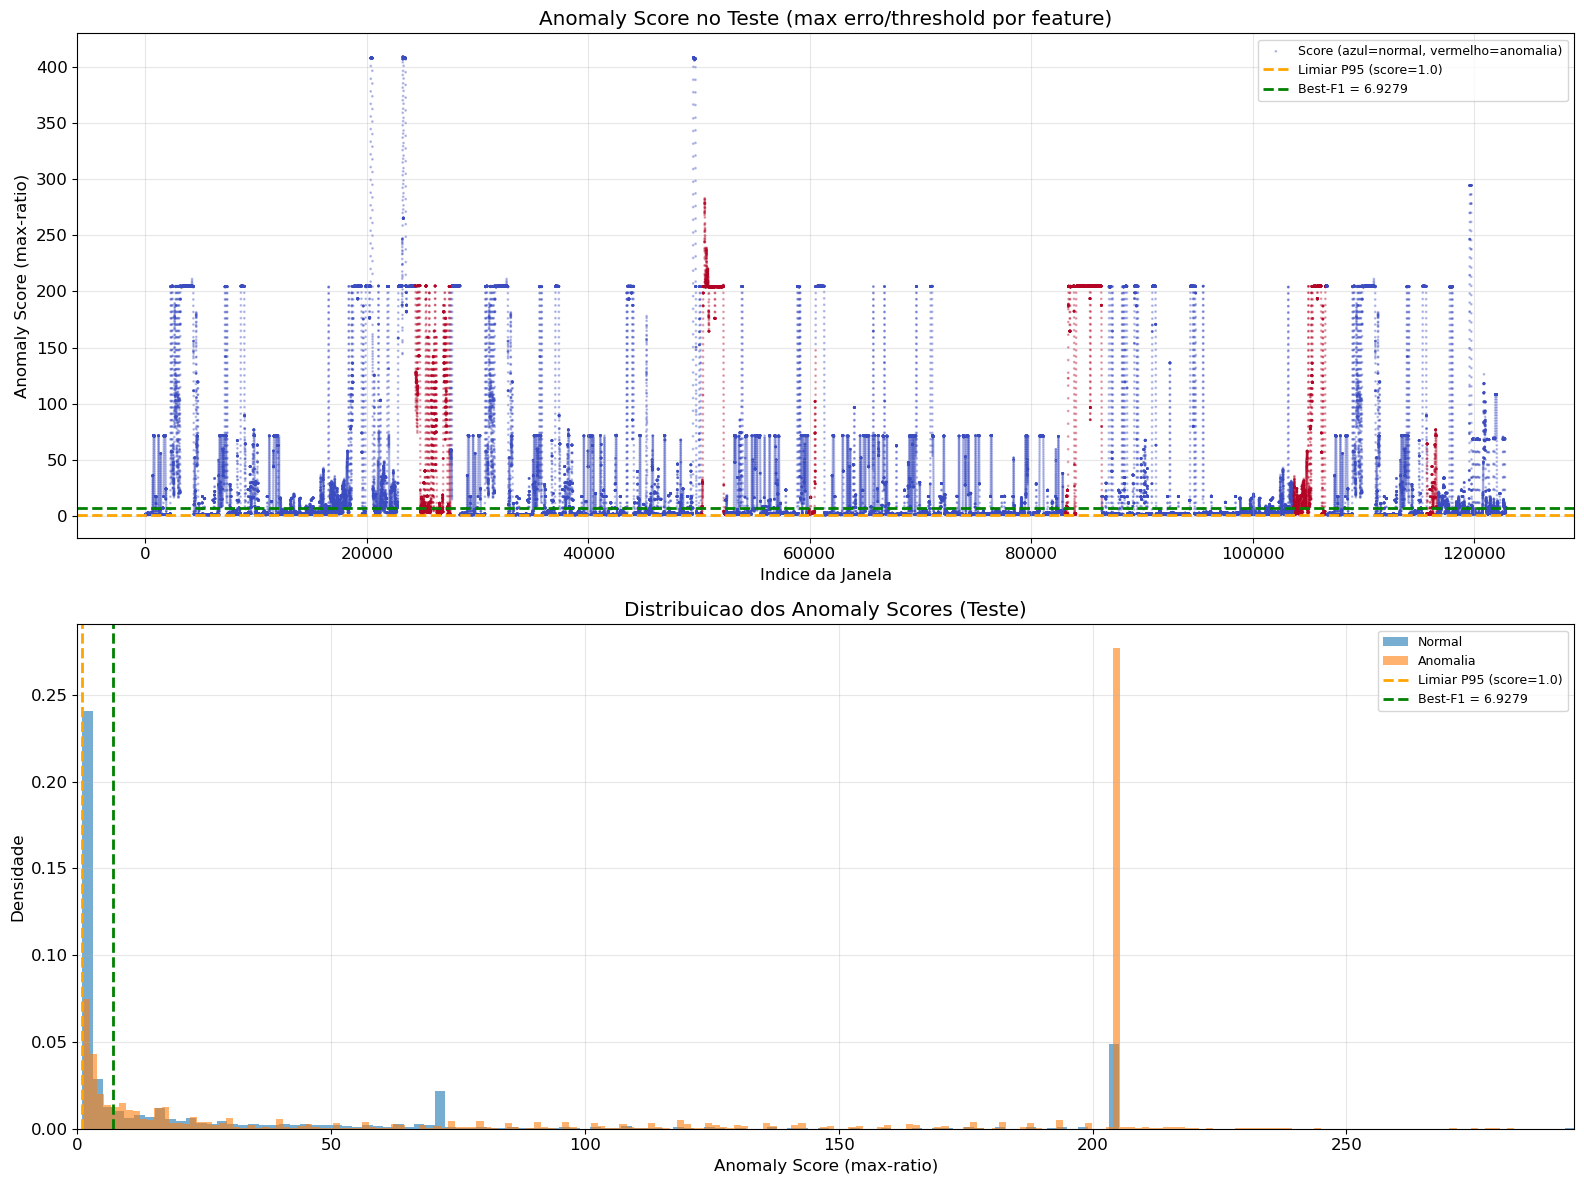

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

ax = axes[0]
ax.scatter(range(len(scores_test_all)), scores_test_all, c=y_test, cmap='coolwarm',
           s=1, alpha=0.3, label='Score (azul=normal, vermelho=anomalia)')
ax.axhline(y=1.0, color='orange', linestyle='--', linewidth=2,
           label='Limiar P95 (score=1.0)')
ax.axhline(y=threshold_best_f1_score, color='green', linestyle='--', linewidth=2,
           label=f'Best-F1 = {threshold_best_f1_score:.4f}')
ax.set_xlabel('Indice da Janela')
ax.set_ylabel('Anomaly Score (max-ratio)')
ax.set_title('Anomaly Score no Teste (max erro/threshold por feature)')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(scores_test_all[y_test == 0], bins=200, alpha=0.6, label='Normal', density=True)
ax.hist(scores_test_all[y_test == 1], bins=200, alpha=0.6, label='Anomalia', density=True)
ax.axvline(x=1.0, color='orange', linestyle='--', linewidth=2,
           label='Limiar P95 (score=1.0)')
ax.axvline(x=threshold_best_f1_score, color='green', linestyle='--', linewidth=2,
           label=f'Best-F1 = {threshold_best_f1_score:.4f}')
ax.set_xlabel('Anomaly Score (max-ratio)')
ax.set_ylabel('Densidade')
ax.set_title('Distribuicao dos Anomaly Scores (Teste)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, np.percentile(scores_test_all, 99.5))

plt.tight_layout()
plt.show()

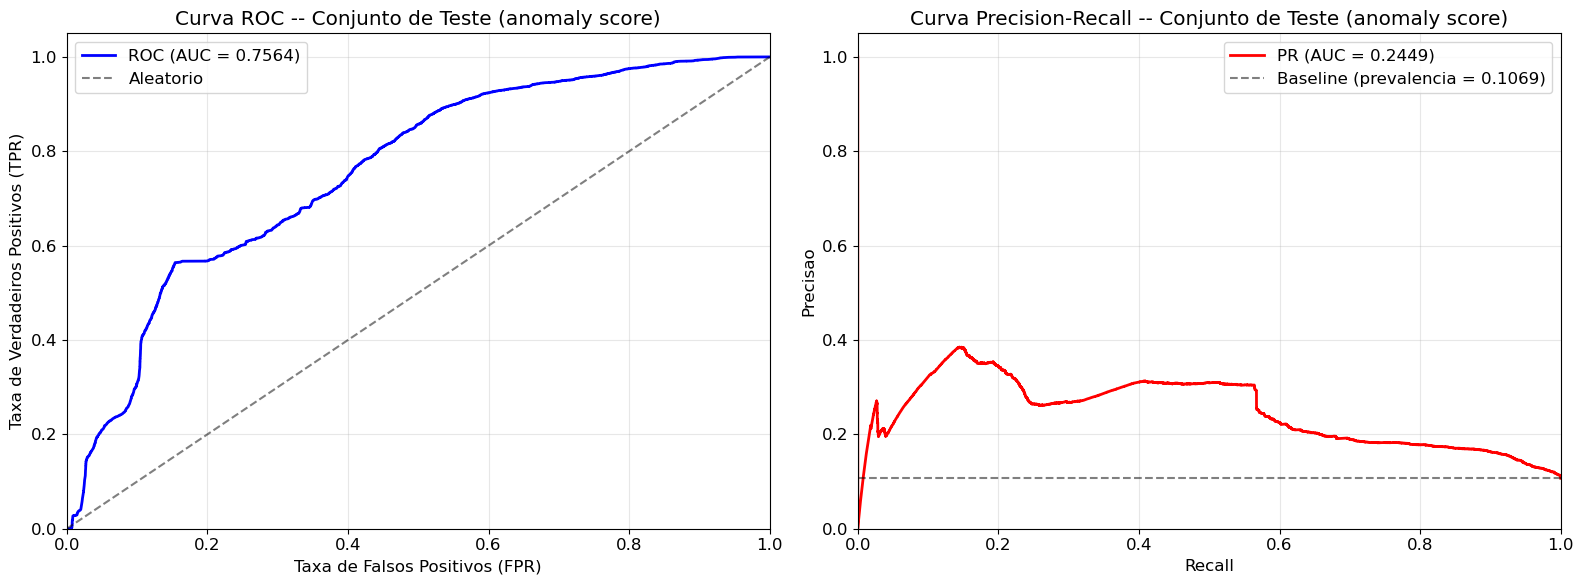

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

fpr, tpr, _ = roc_curve(y_test, scores_test_all)
roc_auc_val_plot = auc(fpr, tpr)
ax1.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {roc_auc_val_plot:.4f})')
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatorio')
ax1.set_xlabel('Taxa de Falsos Positivos (FPR)')
ax1.set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
ax1.set_title('Curva ROC -- Conjunto de Teste (anomaly score)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1.05])

prec_test, rec_test, _ = precision_recall_curve(y_test, scores_test_all)
pr_auc_val_plot = auc(rec_test, prec_test)
ax2.plot(rec_test, prec_test, 'r-', linewidth=2,
         label=f'PR (AUC = {pr_auc_val_plot:.4f})')
baseline = y_test.sum() / len(y_test)
ax2.axhline(y=baseline, color='k', linestyle='--', alpha=0.5,
            label=f'Baseline (prevalencia = {baseline:.4f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precisao')
ax2.set_title('Curva Precision-Recall -- Conjunto de Teste (anomaly score)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

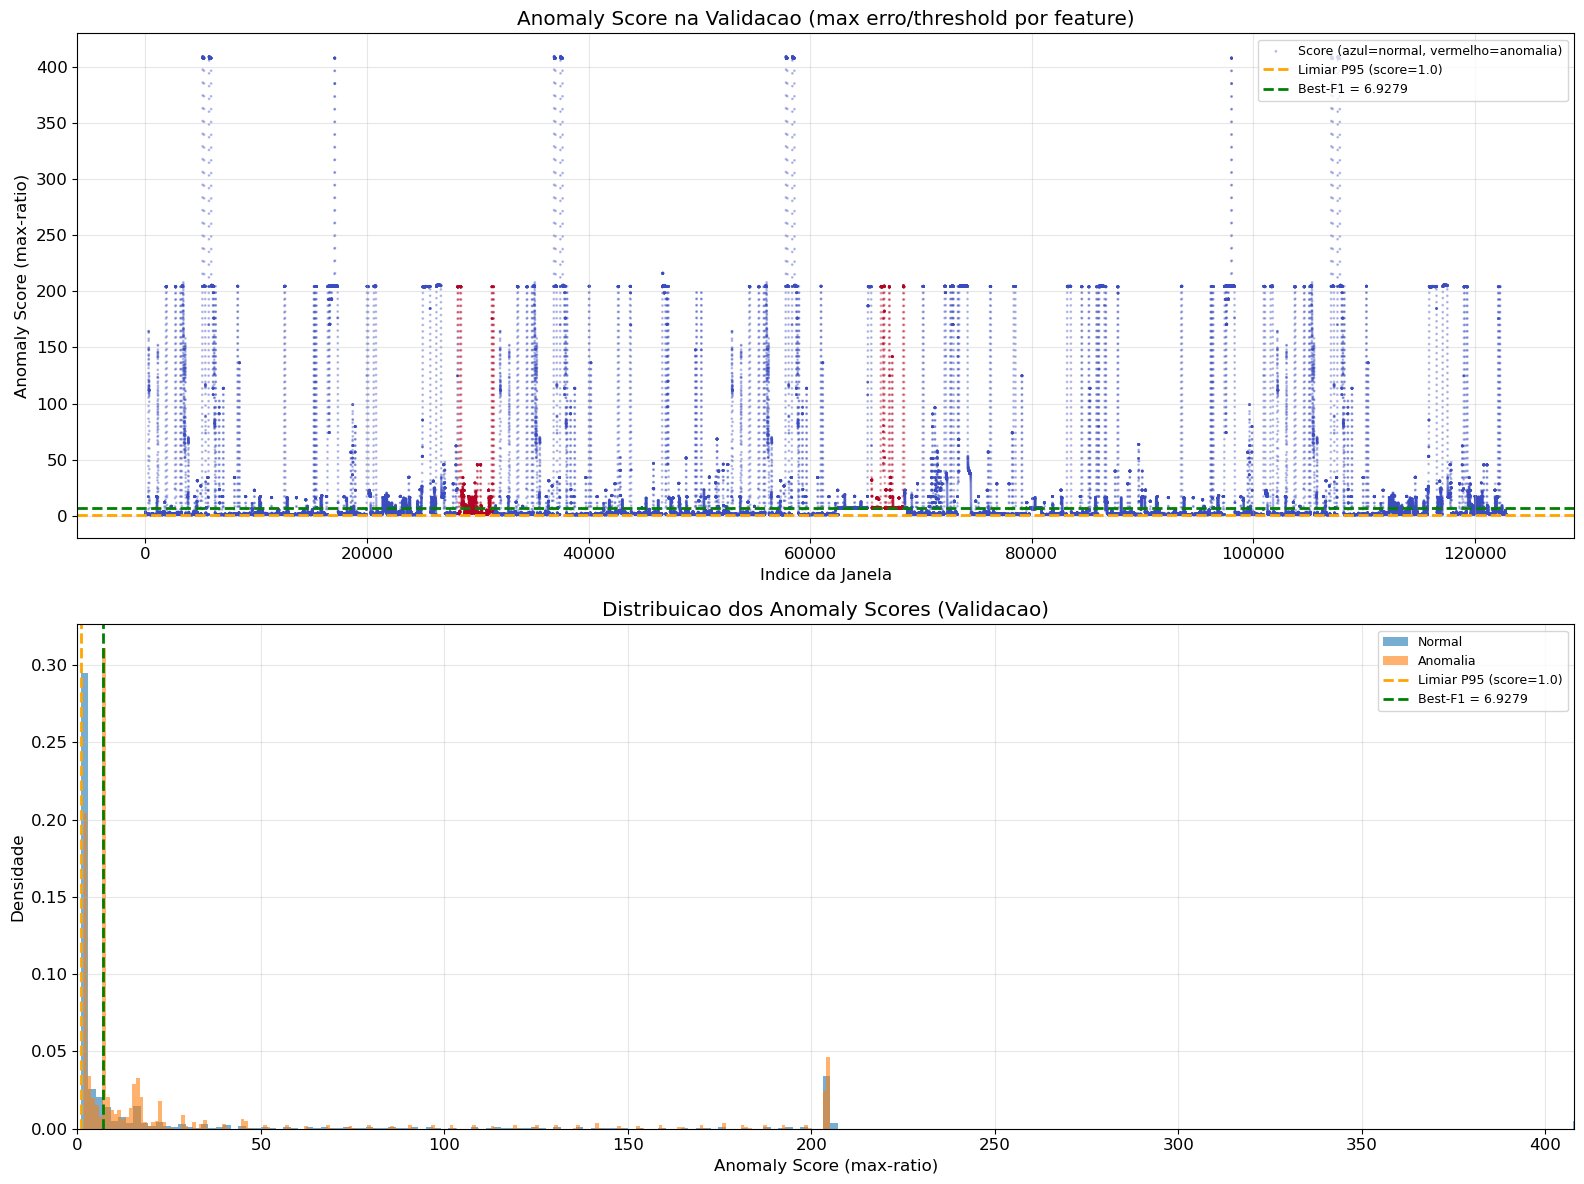

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

ax = axes[0]
ax.scatter(range(len(scores_val_all)), scores_val_all, c=y_val, cmap='coolwarm',
           s=1, alpha=0.3, label='Score (azul=normal, vermelho=anomalia)')
ax.axhline(y=1.0, color='orange', linestyle='--', linewidth=2,
           label='Limiar P95 (score=1.0)')
ax.axhline(y=threshold_best_f1_score, color='green', linestyle='--', linewidth=2,
           label=f'Best-F1 = {threshold_best_f1_score:.4f}')
ax.set_xlabel('Indice da Janela')
ax.set_ylabel('Anomaly Score (max-ratio)')
ax.set_title('Anomaly Score na Validacao (max erro/threshold por feature)')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(scores_val_all[y_val == 0], bins=200, alpha=0.6, label='Normal', density=True)
ax.hist(scores_val_all[y_val == 1], bins=200, alpha=0.6, label='Anomalia', density=True)
ax.axvline(x=1.0, color='orange', linestyle='--', linewidth=2,
           label='Limiar P95 (score=1.0)')
ax.axvline(x=threshold_best_f1_score, color='green', linestyle='--', linewidth=2,
           label=f'Best-F1 = {threshold_best_f1_score:.4f}')
ax.set_xlabel('Anomaly Score (max-ratio)')
ax.set_ylabel('Densidade')
ax.set_title('Distribuicao dos Anomaly Scores (Validacao)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, np.percentile(scores_val_all, 99.5))

plt.tight_layout()
plt.show()

## 12. Salvamento de Artefatos

Salvamento do modelo treinado, scaler de normalizacao, lista de features selecionadas
e thresholds para uso posterior em producao ou analises futuras.

In [23]:
model_path = os.path.join(OUTPUT_DIR, 'modelo_cnn_bilstm_attention_autoencoder.pth')
torch.save({
    'model_state_dict': model.state_dict(),
    'n_features': n_features,
    'timesteps': WINDOW_SIZE,
    'architecture': 'CNNBiLSTMAttentionAutoencoder',
    'best_val_loss': best_val_loss,
    'train_losses': train_losses,
    'val_losses': val_losses,
    'lr_history': lr_history,
    'dropout_rate': DROPOUT_RATE,
    'loss_function': 'MAE (L1Loss)',
    'bidirectional_encoder': True,
}, model_path)
print(f"Modelo salvo: {model_path}")

scaler_path = os.path.join(OUTPUT_DIR, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"Scaler salvo: {scaler_path}")

features_path = os.path.join(OUTPUT_DIR, 'features_selecionadas.json')
with open(features_path, 'w') as f:
    json.dump({
        'selected_features': selected_features,
        'n_original_features': len(sensor_cols),
        'n_selected_features': len(selected_features),
        'selection_method': 'XGBoost top 30% (com scale_pos_weight)',
    }, f, indent=2, ensure_ascii=False)
print(f"Features salvas: {features_path}")

thresholds_pf_p95_path = os.path.join(OUTPUT_DIR, 'thresholds_per_feature_p95.npy')
np.save(thresholds_pf_p95_path, thresholds_pf_p95)
thresholds_pf_p99_path = os.path.join(OUTPUT_DIR, 'thresholds_per_feature_p99.npy')
np.save(thresholds_pf_p99_path, thresholds_pf_p99)
print(f"Thresholds per-feature salvos: P95 ({thresholds_pf_p95_path}), P99 ({thresholds_pf_p99_path})")

thresholds_path = os.path.join(OUTPUT_DIR, 'thresholds.json')
with open(thresholds_path, 'w') as f:
    json.dump({
        'threshold_type': 'per-feature',
        'threshold_best_f1_score': threshold_best_f1_score,
        'min_features_exceed': MIN_FEATURES_EXCEED,
        'computed_on': 'janelas saudaveis de validacao (P95/P99 per-feature) e curva PR (Best-F1 no anomaly score)',
        'metrics_teste_p95': metrics_test_p95,
        'metrics_teste_p99': metrics_test_p99,
        'metrics_teste_best_f1': metrics_test_bf1,
        'auc_roc_test': auc_roc_test,
        'auc_pr_test': auc_pr_test,
        'auc_roc_val': auc_roc_val,
        'auc_pr_val': auc_pr_val,
    }, f, indent=2, ensure_ascii=False)
print(f"Thresholds metadata salvos: {thresholds_path}")

print(f"\nArtefatos salvos no diretorio: {os.path.abspath(OUTPUT_DIR)}/")

Modelo salvo: artefatos_v3\modelo_cnn_bilstm_attention_autoencoder.pth
Scaler salvo: artefatos_v3\scaler.pkl
Features salvas: artefatos_v3\features_selecionadas.json
Thresholds per-feature salvos: P95 (artefatos_v3\thresholds_per_feature_p95.npy), P99 (artefatos_v3\thresholds_per_feature_p99.npy)
Thresholds metadata salvos: artefatos_v3\thresholds.json

Artefatos salvos no diretorio: c:\Users\tibis\OneDrive\Desktop\IC_WIND_THIAGO\artefatos_v3/


## Conclusao

Este notebook (v3) implementou um pipeline de deteccao de anomalias em turbinas
eolicas utilizando dados SCADA do Wind Farm C com arquitetura e pipeline aprimorados:

1. **Pre-processamento**: forward fill de valores ausentes e normalizacao Min-Max (sem clipping)
2. **Selecao de features**: XGBoost com `scale_pos_weight` para lidar com desbalanceamento
3. **Modelo**: CNN-BiLSTM-Attention Autoencoder com LSTMs bidirecionais e Multi-Head
   Self-Attention (4 heads, embed_dim=160) no encoder
4. **Treinamento**: MAE (L1Loss), batch size=128, scheduler ReduceLROnPlateau
5. **Deteccao**: thresholds per-feature (P95/P99) com `MIN_FEATURES_EXCEED` configuravel,
   anomaly score via max-ratio, Best-F1 otimizado via curva PR
6. **Avaliacao**: F1, Acuracia, Precisao, Recall, AUC-ROC, AUC-PR + avaliacao por evento

### Melhorias em relacao a v2
- **BiLSTM**: encoder com LSTMs bidirecionais para captura de contexto temporal bidirecional
- **MAE**: loss L1 mais robusta a outliers que MSE
- **Threshold per-feature**: cada feature tem seu proprio limiar, permitindo deteccao mais
  granular. Anomaly score = max(error_i / threshold_i) para metricas continuas
- **FAST_MODE**: variaveis para limitar CSVs carregados e janelas de treino, acelerando
  iteracoes experimentais
- **Atencao**: Multi-Head Self-Attention com conexao residual e LayerNorm

### Melhorias herdadas da v2
- Dropout reduzido preserva melhor a capacidade de reconstrucao do autoencoder
- Batch size maior acelera o treinamento significativamente
- Scheduler adapta o learning rate automaticamente quando o loss estagna
- scale_pos_weight no XGBoost melhora a selecao de features em cenario desbalanceado
- Metricas AUC avaliam o modelo independente da escolha de threshold
- Avaliacao por evento mostra o impacto pratico da deteccao

Todos os artefatos (modelo, scaler, features, thresholds per-feature) foram salvos em
`artefatos_v3/` para reproducibilidade e uso em producao.